# CASA0007 
## Practical 2: Exploratory Data Analysis 2

<div style="float:right"><img width="100" src="https://github.com/jreades/i2p/raw/master/img/casa_logo.jpg" /></div>

## Welcome!

In this practical, we will apply the exploratory data analysis techinques to explore the distribution of datasets. 

- Normal distribution 
- Exponentials 
- Logarithms 

In [1]:
# import relevant packages

import numpy as np
import scipy.stats as sps
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Background 

We're going to continue exploring the schools dataset here. Need a link to the data.

In [2]:
base = "data/Performancetables_130242/2022-2023/"
na_vals = ["", "NA", "SUPP", "NP", "NE", "SP", "SN", "SUPPMAT"]
df_ks4 = pd.read_csv(base + "england_ks4final.csv", na_values=na_vals)

df_ks4.head()

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_3377/2392795188.py:3: DtypeWarning: Columns (75,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,144,145,146,147,148,149,150,151,152,177,178,179,180,181,182,183,186,187,188,189,190,191,192,194,195,196,198,199,200,202,203,204,206,207,208,210,211,212,214,215,216,218,219,220,222,223,224,230,233,234,235,236,237,238,239,242,243,244,245,246,247,248,251,252,253,254,255,256,257,266,267,268,269,270,271,272,281,282,283,284,285,286,287,296,297,298,299,300,301,302,311,312,313,314,315,316,317,335,336,337,340,341,342,345,346,347,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ks4 = pd.read_csv(base + "england_ks4final.csv", na_values=na_vals)


,RECTYPE,LEA,ESTAB,URN,SCHNAME,SCHNAME_AC,ADDRESS1,ADDRESS2,ADDRESS3,TOWN,...,TAVENT_GFSM6CLA1A_PTQ_EE,TAVENT_GNFSM6CLA1A_PTQ_EE,TAVENT_GFSM6CLA1A_21_PTQ_EE,TAVENT_GNFSM6CLA1A_21_PTQ_EE,TAVENT_GFSM6CLA1A_22_PTQ_EE,TAVENT_GNFSM6CLA1A_22_PTQ_EE,TTOTENT_E_TOTAL_PTQ_EE,TTOTENT_E_COVID_IMPACTED_PTQ_EE,PTOTENT_E_COVID_IMPACTED_PTQ_EE,P8_BANDING
0,1,201.0,6007.0,100003.0,City of London School,NaN,107 Queen Victoria Street,NaN,NaN,London,...,NaN,NaN,NaN,NaN,NaN,NaN,569.0,3.0,1%,NaN
1,1,201.0,6005.0,100001.0,City of London School for Girls,NaN,St Giles' Terrace,Barbican,NaN,London,...,NaN,NaN,NaN,NaN,NaN,NaN,606.0,5.0,1%,NaN
2,1,201.0,6000.0,100544.0,David Game College,NaN,31 Jewry Street,London,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,53.0,1.0,2%,NaN
3,4,201.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,202.0,4285.0,100053.0,Acland Burghley School,NaN,Burghley Road,NaN,NaN,London,...,7.0,8.1,NaN,NaN,7.0,8.2,1397.0,0.0,0%,Average


In [3]:
info_cols = ['RECTYPE', 'LEA', 'SCHNAME', 'TOTPUPS']
ebaccs_cols = ['EBACCAPS', 'EBACCAPS_LO', 'EBACCAPS_MID', 'EBACCAPS_HI']

df = df_ks4[info_cols + ebaccs_cols]

# work on a copy of the dataframe to avoid SettingWithCopyWarning
df = df.copy()

df.head()

,RECTYPE,LEA,SCHNAME,TOTPUPS,EBACCAPS,EBACCAPS_LO,EBACCAPS_MID,EBACCAPS_HI
0,1,201.0,City of London School,1045,2.10,NaN,NaN,NaN
1,1,201.0,City of London School for Girls,739,1.51,NaN,NaN,NaN
2,1,201.0,David Game College,365,0.56,NaN,NaN,NaN
3,4,201.0,NaN,0,NaN,NaN,NaN,NaN
4,1,202.0,Acland Burghley School,1163,4.62,1.91,3.81,6.87


In [4]:
rows, cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 5813, Columns: 8


In [5]:
# get data types for each column
df.dtypes

RECTYPE           int64
LEA             float64
SCHNAME          object
TOTPUPS          object
EBACCAPS        float64
EBACCAPS_LO     float64
EBACCAPS_MID    float64
EBACCAPS_HI     float64
dtype: object

In [6]:
df.loc[:, ebaccs_cols] = df.loc[:, ebaccs_cols].apply(pd.to_numeric, errors='coerce')
df['TOTPUPS'] = pd.to_numeric(df['TOTPUPS'], errors='coerce').fillna(0).astype('int64')

In [7]:
# get data types for each column
df.dtypes

RECTYPE           int64
LEA             float64
SCHNAME          object
TOTPUPS           int64
EBACCAPS        float64
EBACCAPS_LO     float64
EBACCAPS_MID    float64
EBACCAPS_HI     float64
dtype: object

In [8]:
# print how much data is missing for each column
df.isna().mean() * 100 

RECTYPE          0.000000
LEA              0.034406
SCHNAME          2.683640
TOTPUPS          0.000000
EBACCAPS        17.684500
EBACCAPS_LO     38.775159
EBACCAPS_MID    41.149148
EBACCAPS_HI     42.490969
dtype: float64

In [9]:
# return rows where SCHNAME is missing
df[df['SCHNAME'].isna()]

,RECTYPE,LEA,SCHNAME,TOTPUPS,EBACCAPS,EBACCAPS_LO,EBACCAPS_MID,EBACCAPS_HI
3,4,201.0,NaN,0,NaN,NaN,NaN,NaN
24,4,202.0,NaN,10865,4.36,2.03,4.19,6.33
55,4,203.0,NaN,18998,4.13,2.14,4.21,5.77
88,4,204.0,NaN,15214,4.72,2.32,4.64,6.72
112,4,205.0,NaN,9905,5.12,2.26,4.93,6.90
...,...,...,...,...,...,...,...,...
5748,4,941.0,NaN,31801,3.96,2.16,4.04,6.08
5776,4,942.0,NaN,17442,3.81,2.08,3.85,5.54
5810,4,943.0,NaN,14503,3.97,2.29,3.81,5.80
5811,5,NaN,NaN,4129401,3.88,NaN,NaN,NaN


In [10]:
df = df[df['RECTYPE'].isin([1, 2])].copy()

In [11]:
rows, cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 5657, Columns: 8


In [12]:
numerical_cols = ['TOTPUPS', 'EBACCAPS', 'EBACCAPS_LO', 'EBACCAPS_MID', 'EBACCAPS_HI']

df[numerical_cols].describe()

,TOTPUPS,EBACCAPS,EBACCAPS_LO,EBACCAPS_MID,EBACCAPS_HI
count,5657.000000,4631.000000,3406.000000,3268.000000,3190.000000
mean,726.067527,3.428538,2.090628,4.033562,5.782893
std,554.805752,1.679245,0.769925,0.818922,0.856998
min,0.000000,0.000000,0.000000,0.100000,0.590000
25%,156.000000,2.820000,1.830000,3.560000,5.250000
50%,750.000000,3.700000,2.200000,3.980000,5.820000
75%,1143.000000,4.440000,2.520000,4.470000,6.350000
max,3440.000000,8.700000,5.320000,7.170000,8.730000


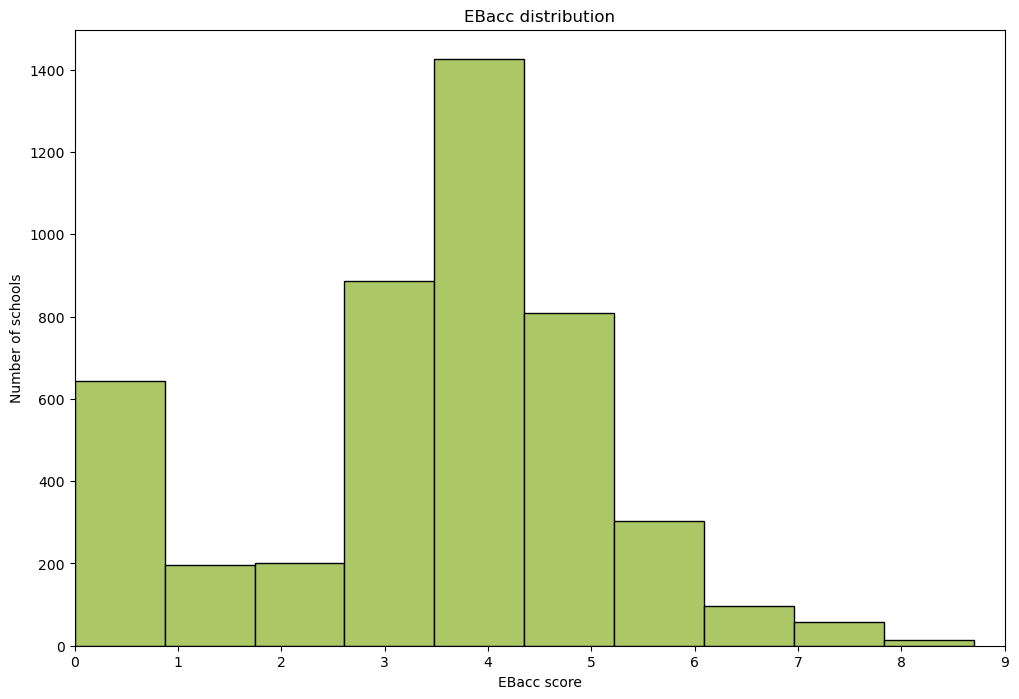

In [13]:
n_bins = 10
fig, ax = plt.subplots(figsize=(12, 8))

ax.hist(df['EBACCAPS'].dropna(), bins=n_bins, color='#abc766', edgecolor='black')
ax.set_title('EBacc distribution')
ax.set_xlabel('EBacc score')
ax.set_ylabel('Number of schools')  
ax.set_xlim(0,9) # the EBacc has a maximum score of 9

plt.show()

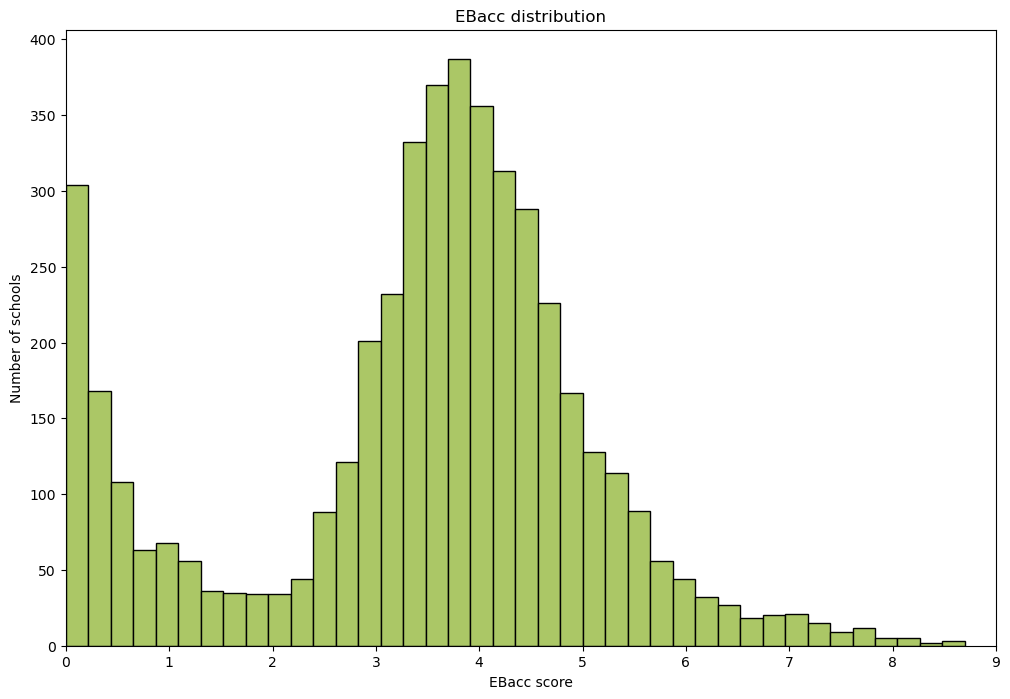

In [14]:
n_bins = 40
fig, ax = plt.subplots(figsize=(12, 8))

ax.hist(df['EBACCAPS'].dropna(), bins=n_bins, color='#abc766', edgecolor='black')
ax.set_title('EBacc distribution')
ax.set_xlabel('EBacc score')
ax.set_ylabel('Number of schools')  
ax.set_xlim(0,9) # the EBacc has a maximum score of 9

plt.show()

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_3377/3509817750.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'k', linewidth=2, color="#e16fca")


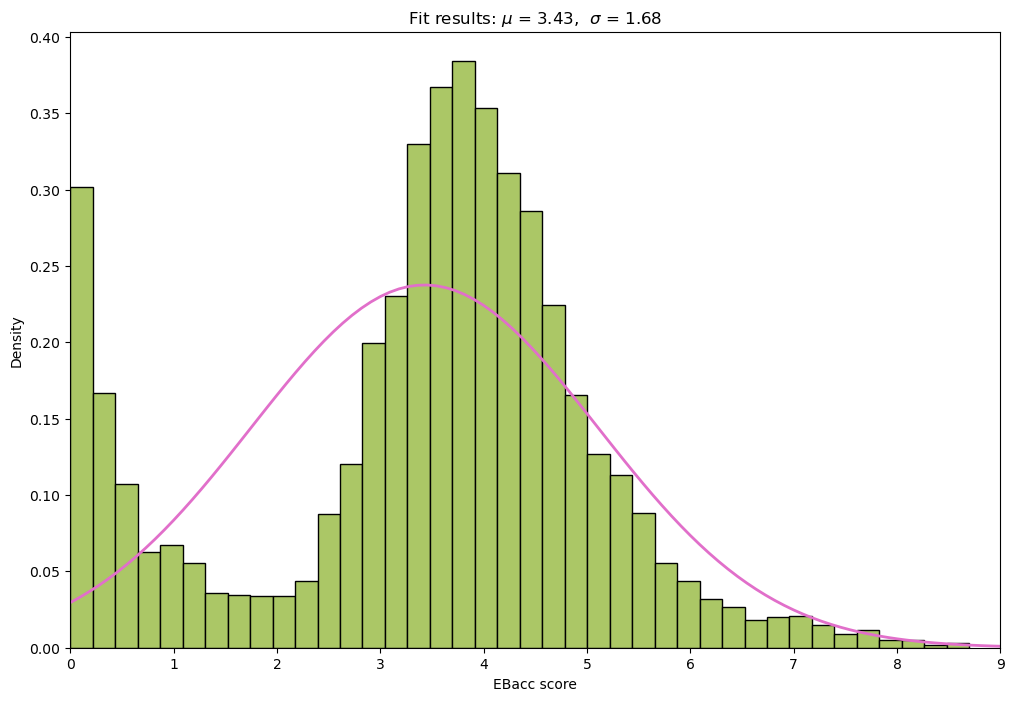

In [15]:
import scipy.stats as sps

# first let's get the mean and stand deviation 
mu = df['EBACCAPS'].dropna().mean()
std = df['EBACCAPS'].dropna().std()

## Create the plot 

# plot the histogram
plt.figure(figsize=(12, 8))
plt.hist(df['EBACCAPS'], bins=40, density=True, color='#abc766', edgecolor='black')

# plot the Probability Density Function (PDF)
xmin = 0 
xmax = 9
x = np.linspace(xmin, xmax, 100)
p = sps.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, color="#e16fca")

plt.title(f"Fit results: $\mu$ = {mu:.2f},  $\sigma$ = {std:.2f}")
plt.xlim(0, 9)
plt.xlabel("EBacc score")
plt.ylabel("Density")

plt.show()

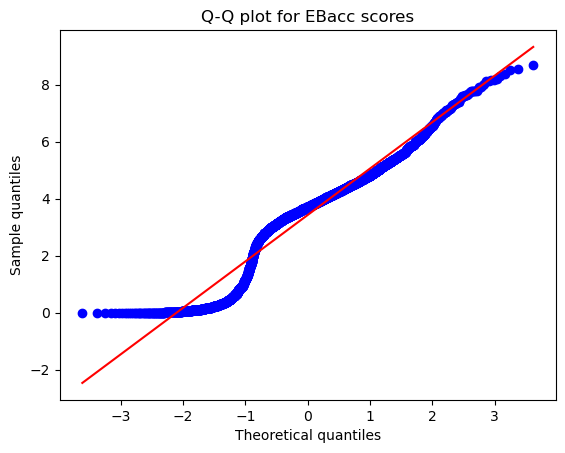

In [16]:
# Q-Q plot
sps.probplot(df['EBACCAPS'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q plot for EBacc scores")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Sample quantiles")
plt.show()

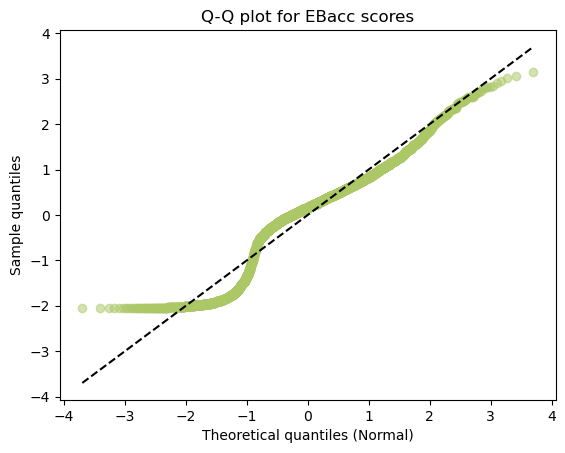

In [17]:
# Drop missing values
data = df['EBACCAPS'].dropna().values
n = len(data)

# normalise the data
data = (data - np.mean(data)) / np.std(data)

# Sort the sample data
sample_quantiles = np.sort(data)

# Compute plotting positions (probabilities)
p = (np.arange(1, n+1) - 0.5) / n

# Compute theoretical quantiles from standard normal
theoretical_quantiles = sps.norm.ppf(p)

# Plot
plt.scatter(theoretical_quantiles, sample_quantiles, alpha=0.5, color='#abc766')
plt.plot(theoretical_quantiles, theoretical_quantiles, color='black', linestyle='--')  # reference line
plt.title("Q-Q plot for EBacc scores")
plt.xlabel("Theoretical quantiles (Normal)")
plt.ylabel("Sample quantiles")

plt.show()

In [18]:
sample_quantiles

array([-2.04193425, -2.04193425, -2.04193425, ...,  3.02041027,
        3.05614447,  3.13952426])

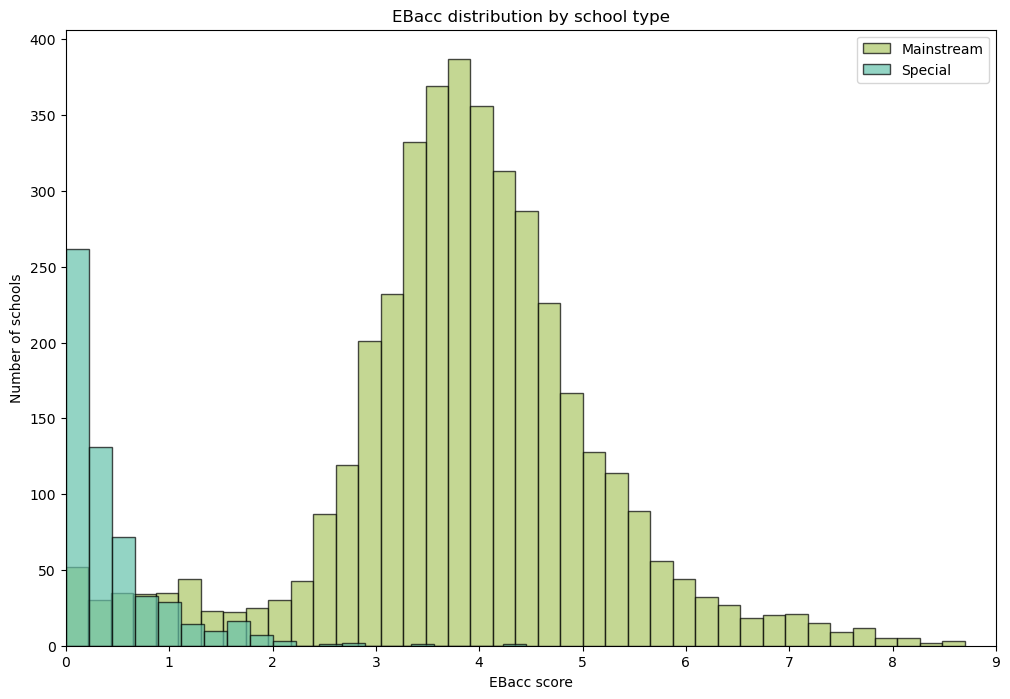

In [19]:
# histogram of # plot histogram of EBACCAPS by RECTYPE
n_bins = {1:40, 2:20}
fig, ax = plt.subplots(figsize=(12, 8))
for rectype, color, label in zip([1, 2], ['#abc766', '#66c2ab'], ['Mainstream', 'Special']):
    ax.hist(df_ks4.loc[df_ks4['RECTYPE'] == rectype, 'EBACCAPS'].dropna(), bins=n_bins[rectype], alpha=0.7, color=color, edgecolor='black', label=label)
ax.set_title('EBacc distribution by school type')
ax.set_xlabel('EBacc score')
ax.set_ylabel('Number of schools')  
ax.set_xlim(0,9)
ax.legend()

plt.show()

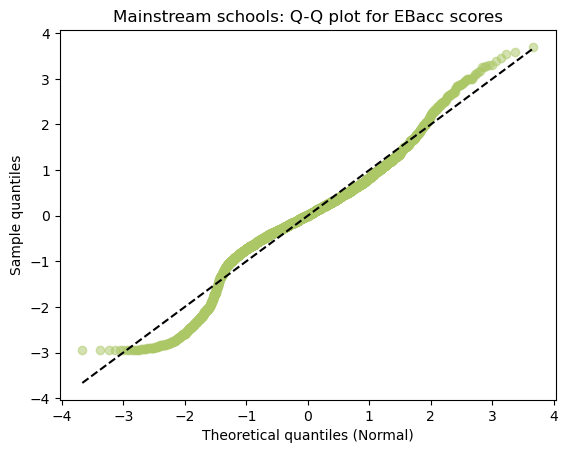

In [20]:
## create q-q plots by RECTYPE

## start with RECTYPE = 1
df1 = df[df['RECTYPE'] == 1]

# Drop missing values
data = df1['EBACCAPS'].dropna().values
n = len(data)

# normalise the data
data = (data - np.mean(data)) / np.std(data)

# Sort the sample data
sample_quantiles = np.sort(data)

# Compute plotting positions (probabilities)
p = (np.arange(1, n+1) - 0.5) / n

# Compute theoretical quantiles from standard normal
theoretical_quantiles = sps.norm.ppf(p)

# Plot
plt.scatter(theoretical_quantiles, sample_quantiles, alpha=0.5, color='#abc766')
plt.plot(theoretical_quantiles, theoretical_quantiles, color='black', linestyle='--')  # reference line
plt.title("Mainstream schools: Q-Q plot for EBacc scores")
plt.xlabel("Theoretical quantiles (Normal)")
plt.ylabel("Sample quantiles")

plt.show()

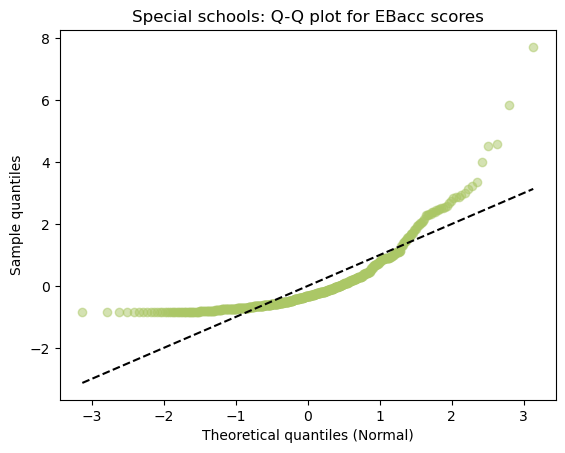

In [21]:
## start with RECTYPE = 2
df2 = df[df['RECTYPE'] == 2]

# Drop missing values
data = df2['EBACCAPS'].dropna().values
n = len(data)

# normalise the data
data = (data - np.mean(data)) / np.std(data)

# Sort the sample data
sample_quantiles = np.sort(data)

# Compute plotting positions (probabilities)
p = (np.arange(1, n+1) - 0.5) / n

# Compute theoretical quantiles from standard normal
theoretical_quantiles = sps.norm.ppf(p)

# Plot
plt.scatter(theoretical_quantiles, sample_quantiles, alpha=0.5, color='#abc766')
plt.plot(theoretical_quantiles, theoretical_quantiles, color='black', linestyle='--')  # reference line
plt.title("Special schools: Q-Q plot for EBacc scores")
plt.xlabel("Theoretical quantiles (Normal)")
plt.ylabel("Sample quantiles")

plt.show()


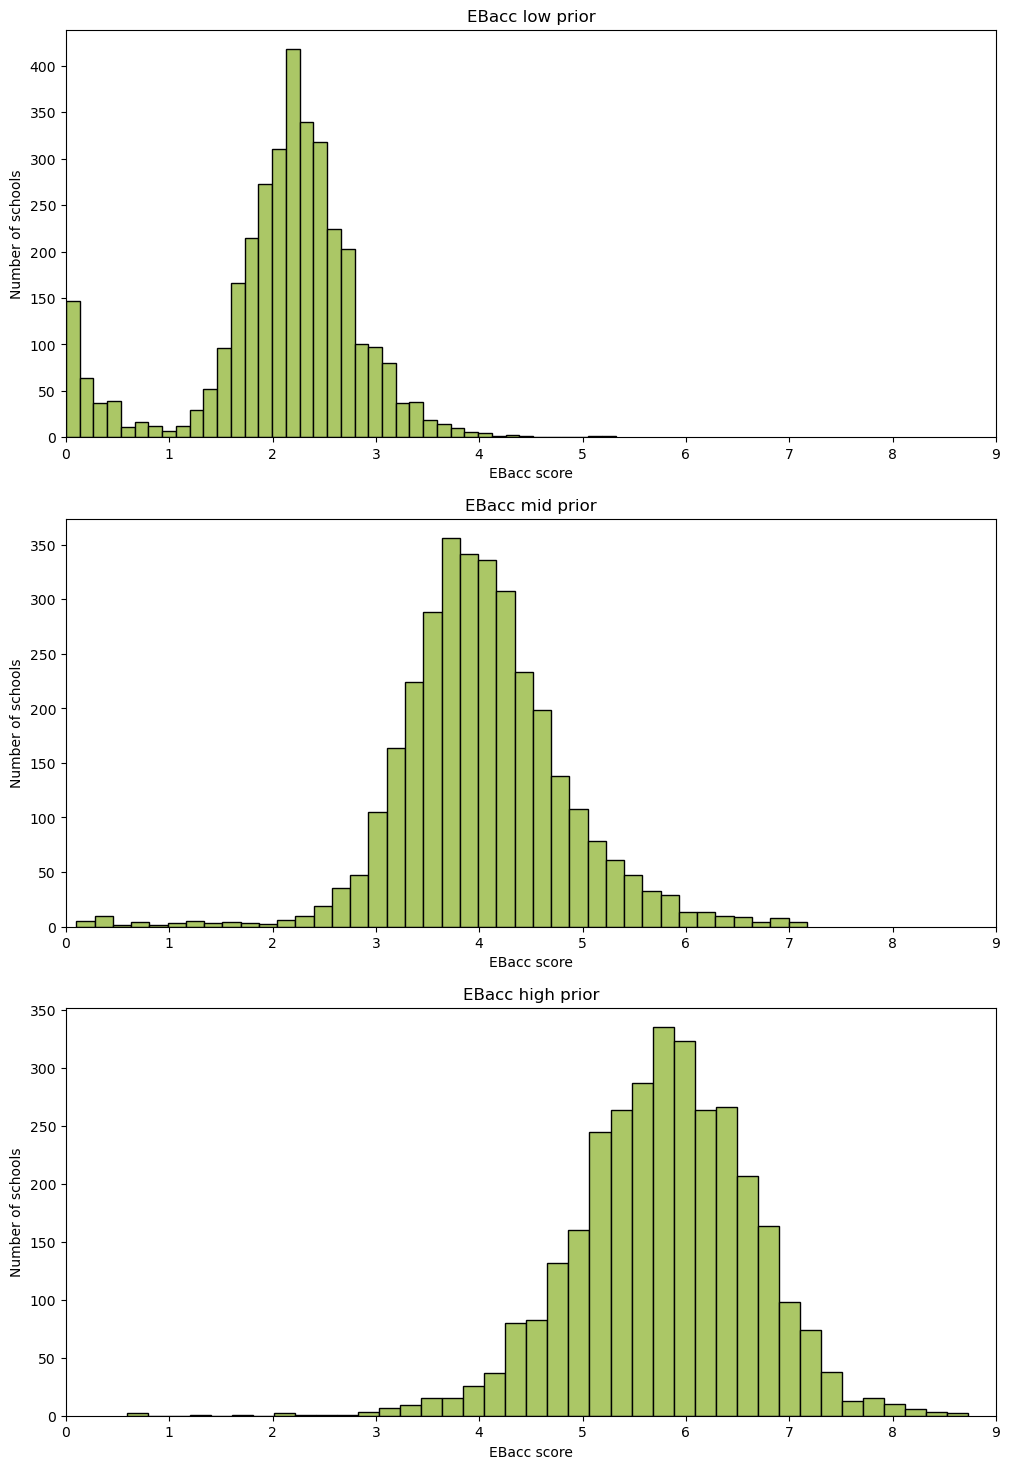

In [22]:
## plot the histograms of 'EBACCAPS_LO', 'EBACCAPS_MID', 'EBACCAPS_HI'

n_bins = 40
fig, ax = plt.subplots(3, 1, figsize=(12, 18))
plot_names = ['EBacc low prior', 'EBacc mid prior', 'EBacc high prior']

for i, col in enumerate(['EBACCAPS_LO', 'EBACCAPS_MID', 'EBACCAPS_HI']):
    ax[i].hist(df[col].dropna(), bins=n_bins, color='#abc766', edgecolor='black')
    ax[i].set_title(plot_names[i])
    ax[i].set_xlabel('EBacc score')
    ax[i].set_ylabel('Number of schools')  
    ax[i].set_xlim(0,9) # the EBacc has a maximum score of 9
plt.show()

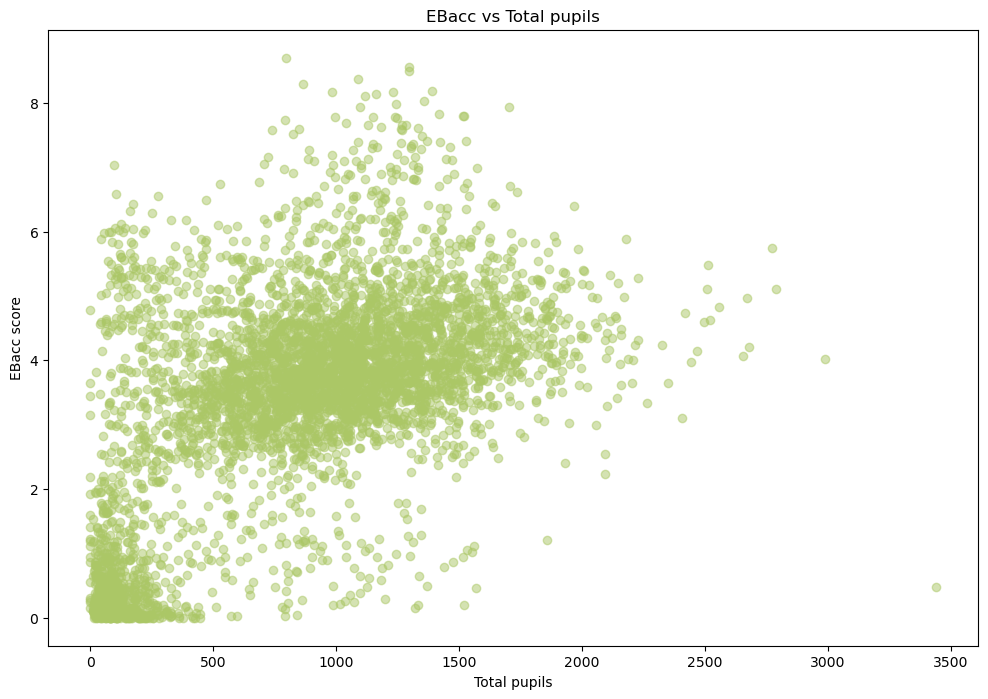

In [23]:
# plot EBACCAPS vs TOTPUPS
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(df['TOTPUPS'], df['EBACCAPS'], alpha=0.5, color='#abc766')
ax.set_title('EBacc vs Total pupils')
ax.set_xlabel('Total pupils')
ax.set_ylabel('EBacc score')
plt.show()